# Calogero-Sutherland Model — Exact Wavefunction Test

**Hamiltonian** (convention $\hbar^2/m = 1$, so kinetic $= -\sum_i \partial^2/\partial x_i^2$):

$$H = -\sum_i \frac{\partial^2}{\partial x_i^2} + \sum_i x_i^2 + 2L(L-1) \sum_{i<j} \frac{1}{(x_i - x_j)^2}$$

**Exact ground state:**

$$\psi_0(x) = C \prod_{i<j} |x_i - x_j|^L \cdot \exp\!\left(-\tfrac{1}{2}\sum_i x_i^2\right)$$

$$\log|\psi_0| = L \sum_{i<j} \log|x_i - x_j| - \tfrac{1}{2}\sum_i x_i^2$$

**Exact ground state energy** (in code convention, $\omega=1$):

$$E_0 = N\bigl(1 + L(N-1)\bigr) \qquad \Longrightarrow \qquad E_0/N = 1 + L(N-1)$$

**This notebook trains the exact model** — a single learnable parameter $\lambda$ in the Jastrow factor.
When $\lambda \to L$, the energy converges exactly to $E_0$.

## Imports

In [1]:
import jax
import jax.numpy as jnp
import optax
import numpy as np
import matplotlib.pyplot as plt

from qvarnet.train import train
from qvarnet.config.training_setup import TrainingConfig, CuspConfig
from qvarnet.config.coord_mode import LabCoords
from qvarnet.models.analytic import CalogeroSutherlandAnalyticModel
from qvarnet.models.exponential import JastrowLogExponentialMLPwithGaussianPenalty, LogExponentialMLPwithGaussianPenalty
from qvarnet.hamiltonian.continuous import CalogeroSutherlandHamiltonian

## System

In [2]:
N_PARTICLES = 5     # number of particles
DIM         = 1
L           = 1.1   # CS coupling; exact λ = L in the Jastrow factor

N_CHAINS = 5_000
DoF      = N_PARTICLES * DIM
SHAPE    = (N_CHAINS, DoF)

# Exact energy in code convention (H = -Σ∂² + V, ω=1)
E_EXACT_TOTAL = N_PARTICLES * (1 + L * (N_PARTICLES - 1))
E_EXACT       = E_EXACT_TOTAL / N_PARTICLES   # per particle

print(f"N = {N_PARTICLES},  L = {L}")
print(f"E₀ (total)      = {E_EXACT_TOTAL:.4f}")
print(f"E₀ (per particle) = {E_EXACT:.4f}")

N = 5,  L = 1.1
E₀ (total)      = 27.0000
E₀ (per particle) = 5.4000


## Model

The `CalogeroSutherlandAnalyticModel` implements the exact log-wavefunction with one learnable parameter $\lambda$:

$$\log|\psi| = \lambda \sum_{i<j} \log|x_i - x_j| - \tfrac{1}{2}\sum_i x_i^2$$

Setting `lambda_init = L` starts at the exact solution. Any other starting value tests convergence.

In [3]:
LAMBDA_INIT = 1.2   # starting guess for λ; converges to L during training

# model        = CalogeroSutherlandAnalyticModel(lambda_init=LAMBDA_INIT)
model = LogExponentialMLPwithGaussianPenalty(architecture = [N_PARTICLES, 100, 1])
# model = JastrowLogExponentialMLPwithGaussianPenalty(architecture = [N_PARTICLES, 1], lambda_init=LAMBDA_INIT)
IS_LOG_MODEL = True

print(f"λ init = {LAMBDA_INIT}   →   target λ = {L}")

λ init = 1.2   →   target λ = 1.1


## Hamiltonian

`epsilon` softens the $1/(x_i-x_j)^2$ singularity; set it small but nonzero for numerical stability.

In [4]:
hamiltonian = CalogeroSutherlandHamiltonian(L=L, epsilon=1e-8)

## Optimizer

In [5]:
LEARNING_RATE = 0.001
optimizer     = optax.adam(learning_rate=LEARNING_RATE)

## Sampler

In [6]:
CHAIN_LENGTH = 10

sampler_params = {
    "step_size":            0.5,
    "chain_length":         CHAIN_LENGTH + 1,
    "thermalization_steps": CHAIN_LENGTH,
    "thinning_factor":      1,
    "PBC":                  1.0,
}

## Training

In [7]:
def train_helper(model, epochs, seed1, seed2, with_cusp_condition, n_configs_per_pair, cusp_config=None):
    _cusp_config = CuspConfig(
            epsilon=1e-4,
            n_configs_per_pair=n_configs_per_pair,
            rng_seed=seed2,
            alpha=0.1,
            n=2,       # exponent of the cusp potential term. n -> 1/r^n
            C_n=L,     # expected value of the cusp condition coefficient C_n
        ) if with_cusp_condition else None
    
    _cusp_config = cusp_config if with_cusp_condition else None
    cfg = TrainingConfig(
        n_epochs=epochs,
        rng_seed=seed1,
        warm_walkers=True,
        is_update_step_size=True,
        min_step=1e-5,
        max_step=5.0,
        cusp=_cusp_config,
    )

    result = train(
        shape=SHAPE,
        model=model,
        optimizer=optimizer,
        hamiltonian=hamiltonian,
        training_config=cfg,
        sampler_params=sampler_params,
        coord_mode=LabCoords(),
    )
    return result.history

# Study of the convergence of the energy with and without the cusp condition in the loss

## Cusp condition enabled

0
Training MLP+Jastrow+Gaussian | n_configs=0 | cusp=False | seeds=[7164 9952]


/tmp/ipykernel_26534/579219502.py:22: UserWarning: checkpoint_path is './' (the default) — run outputs will be saved in the current working directory. Set TrainingConfig.checkpoint_path to a named run directory, or pass a RunOutputCallback with an explicit path.
  result = train(
100%|██████████| 2000/2000 [00:14<00:00, 140.02it/s, E=27.0098, sigma_E=0.2836]


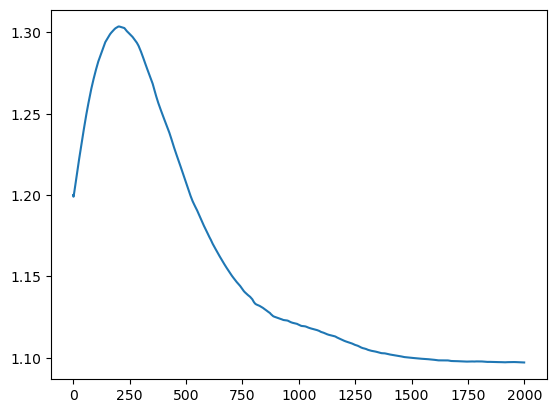

Training MLP+Jastrow+Gaussian | n_configs=0 | cusp=False | seeds=[6374 7251]


100%|██████████| 2000/2000 [00:13<00:00, 143.54it/s, E=27.0041, sigma_E=0.2688]


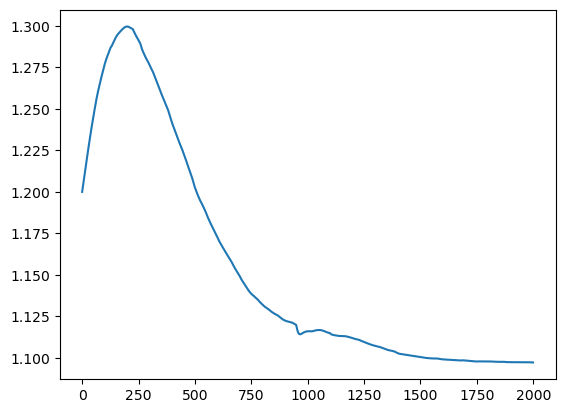

1
Training MLP+Jastrow+Gaussian | n_configs=1 | cusp=True | seeds=[6844 2529]


100%|██████████| 2000/2000 [00:12<00:00, 160.40it/s, E=27.0060, sigma_E=0.3542]


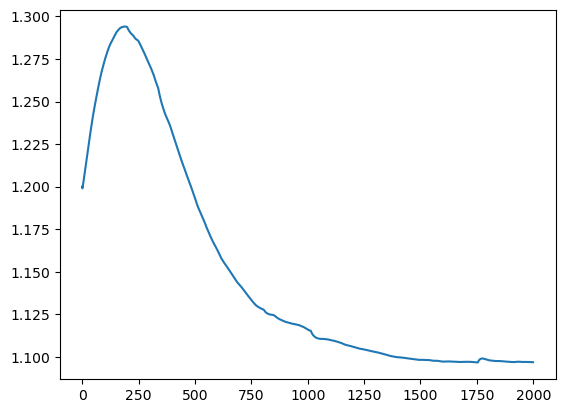

Training MLP+Jastrow+Gaussian | n_configs=1 | cusp=True | seeds=[ 108 1183]


100%|██████████| 2000/2000 [00:12<00:00, 158.92it/s, E=27.0051, sigma_E=0.3558]


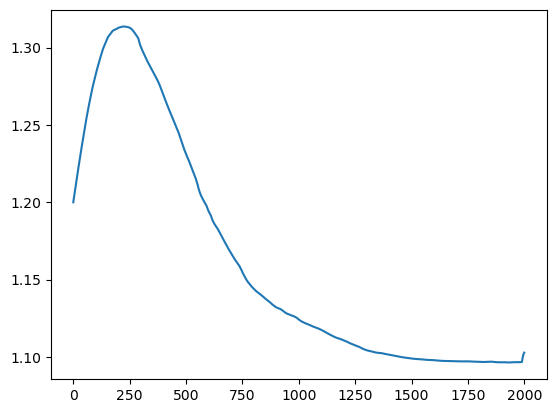

2
Training MLP+Jastrow+Gaussian | n_configs=2 | cusp=True | seeds=[4892  627]


100%|██████████| 2000/2000 [00:14<00:00, 141.60it/s, E=27.0078, sigma_E=0.2711] 


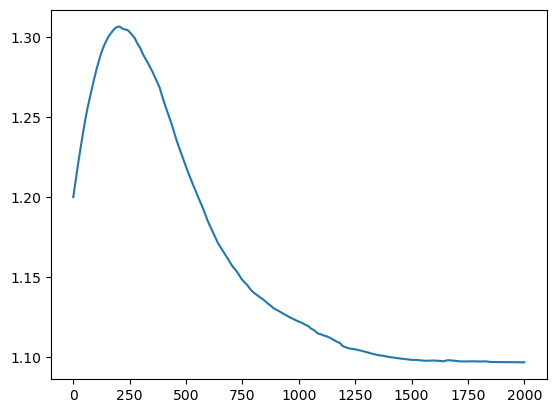

Training MLP+Jastrow+Gaussian | n_configs=2 | cusp=True | seeds=[6742 6294]


100%|██████████| 2000/2000 [00:13<00:00, 146.74it/s, E=27.0086, sigma_E=0.3233] 


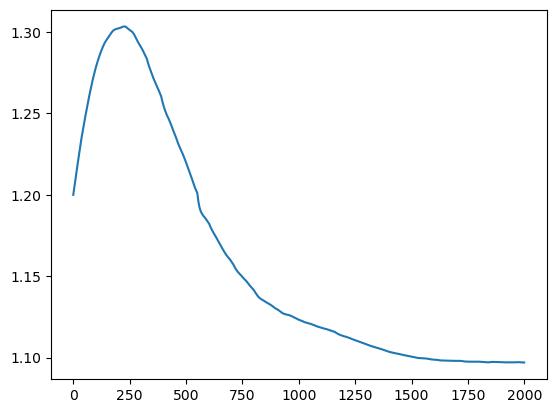

0
Training Analytic | n_configs=0 | cusp=False | seeds=[1228 1299]


100%|██████████| 2000/2000 [00:07<00:00, 270.93it/s, E=27.0000, sigma_E=0.0011]


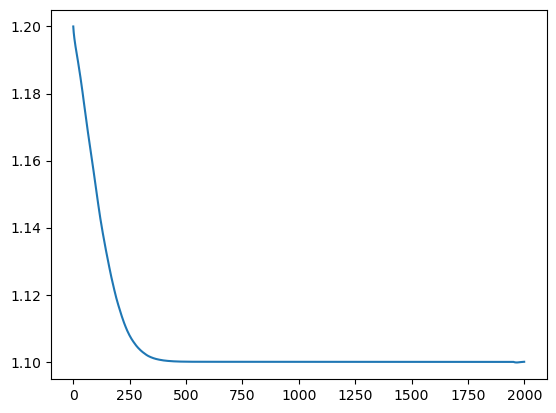

Training Analytic | n_configs=0 | cusp=False | seeds=[5059 8792]


100%|██████████| 2000/2000 [00:07<00:00, 269.04it/s, E=27.0000, sigma_E=0.0001]


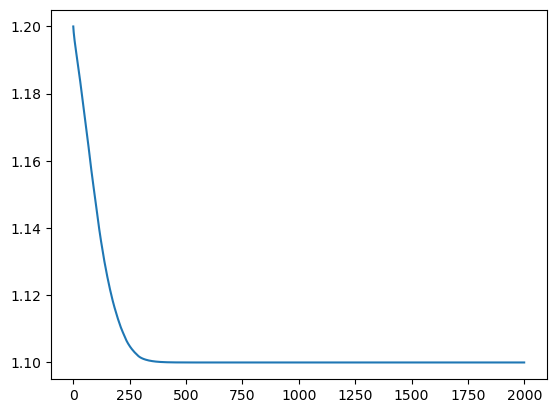

1
Training Analytic | n_configs=1 | cusp=True | seeds=[1320 6346]


100%|██████████| 2000/2000 [00:07<00:00, 268.52it/s, E=27.0000, sigma_E=0.0002]


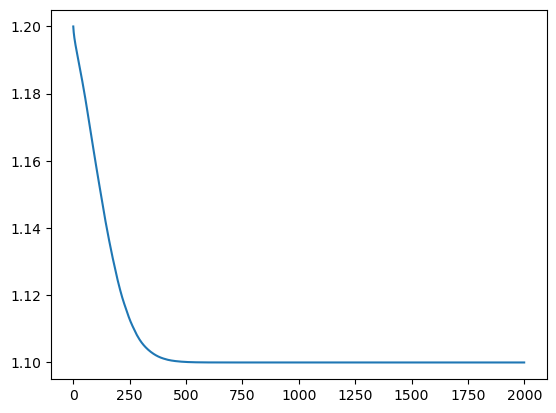

Training Analytic | n_configs=1 | cusp=True | seeds=[6132 8387]


100%|██████████| 2000/2000 [00:07<00:00, 273.02it/s, E=27.0000, sigma_E=0.0000]


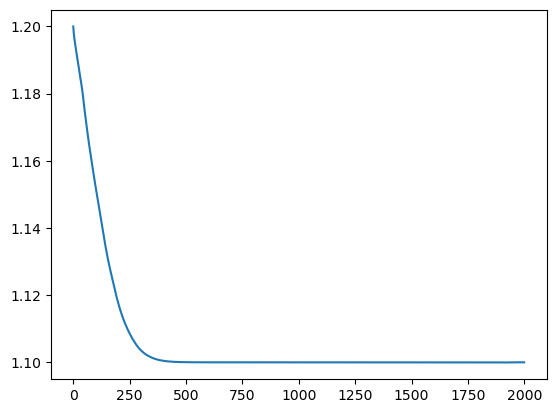

2
Training Analytic | n_configs=2 | cusp=True | seeds=[4592 1629]


100%|██████████| 2000/2000 [00:07<00:00, 265.81it/s, E=27.0000, sigma_E=0.0001]


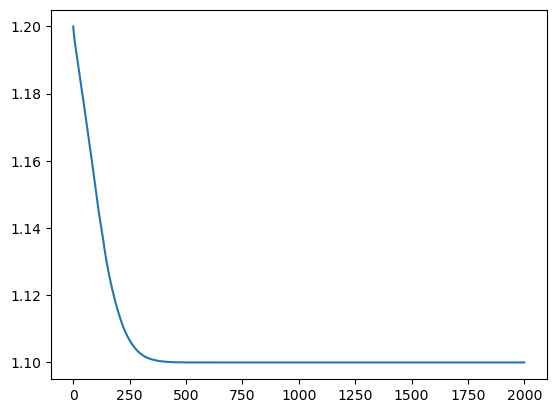

Training Analytic | n_configs=2 | cusp=True | seeds=[7397 1545]


100%|██████████| 2000/2000 [00:07<00:00, 265.08it/s, E=27.0000, sigma_E=0.0000]


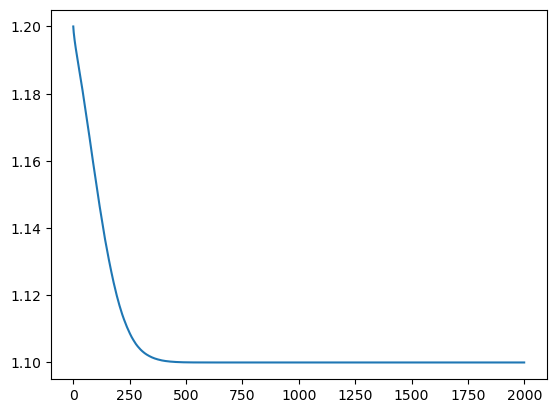

0
Training MLP+Gaussian | n_configs=0 | cusp=False | seeds=[5494 7943]


100%|██████████| 2000/2000 [00:12<00:00, 162.73it/s, E=58.7696, sigma_E=48.2292]      


Training MLP+Gaussian | n_configs=0 | cusp=False | seeds=[3546 9865]


100%|██████████| 2000/2000 [00:12<00:00, 157.63it/s, E=76.9793, sigma_E=95.4917]     


1
Training MLP+Gaussian | n_configs=1 | cusp=True | seeds=[7069 7969]


...

100%|██████████| 2000/2000 [00:12<00:00, 157.63it/s, E=63.1840, sigma_E=38.8592]     


2
Training MLP+Gaussian | n_configs=2 | cusp=True | seeds=[5081 1127]


100%|██████████| 2000/2000 [00:12<00:00, 159.66it/s, E=63.0647, sigma_E=42.3910]      


Training MLP+Gaussian | n_configs=2 | cusp=True | seeds=[1192  877]


100%|██████████| 2000/2000 [00:12<00:00, 155.80it/s, E=76.9902, sigma_E=362.5577]    


In [8]:
analytic_model        = CalogeroSutherlandAnalyticModel(lambda_init=LAMBDA_INIT)
mlp_gaussian          = LogExponentialMLPwithGaussianPenalty(architecture = [N_PARTICLES, 128, 1])
mlp_jastrow_gaussian  = JastrowLogExponentialMLPwithGaussianPenalty(architecture = [N_PARTICLES, 128, 1], lambda_init=LAMBDA_INIT)

models = {
    "MLP+Jastrow+Gaussian": mlp_jastrow_gaussian,
    "Analytic": analytic_model,
    "MLP+Gaussian": mlp_gaussian,
}

n_configs_per_pair = [0, 1, 2]


class ResultsCollector:
    def __init__(self):
        # model_name -> n_configs -> list of run dicts
        self.results = {}

    def add_result(self, model_name, n_configs, history, with_cusp):
        if model_name not in self.results:
            self.results[model_name] = {}
        if n_configs not in self.results[model_name]:
            self.results[model_name][n_configs] = []
        self.results[model_name][n_configs].append({
            "energy":          [float(s.energy) for s in history],
            "std":             [float(s.std) for s in history],
            "acceptance_rate": [float(jnp.mean(s.acceptance_rate)) for s in history],
            "step_size":       [float(s.step_size) for s in history],
            "cusp":            with_cusp,
            "fin_params":      history[-1].params,
        })


collector = ResultsCollector()


for model_name, model in models.items():
    for n_configs in n_configs_per_pair:
        print(n_configs)
        current_seeds = np.random.randint(0, 10000, size=(2, 2))
        if n_configs == 0:
            with_cusp = False  # only cusp condition runs when n_configs=0
        else:
            with_cusp = True
        for seed_tuple in current_seeds:
            print(f"Training {model_name} | n_configs={n_configs} | cusp={with_cusp} | seeds={seed_tuple}")
            history = train_helper(
                model=model, epochs=2000,
                seed1=seed_tuple[0], seed2=seed_tuple[1],
                with_cusp_condition=with_cusp,
                n_configs_per_pair=n_configs,
            )
            if model_name == "MLP+Jastrow+Gaussian" or model_name == "Analytic":
                lambda_values = [float(s.params["params"]["lam"]) for s in history]
                plt.plot(lambda_values, label=f"n_configs={n_configs}, cusp={with_cusp}")
                plt.show()
            collector.add_result(model_name, n_configs, history, with_cusp)


Model: MLP+Jastrow+Gaussian
0 n_configs


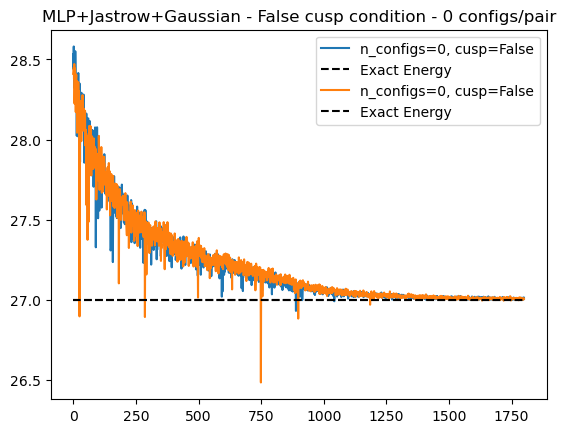

1 n_configs


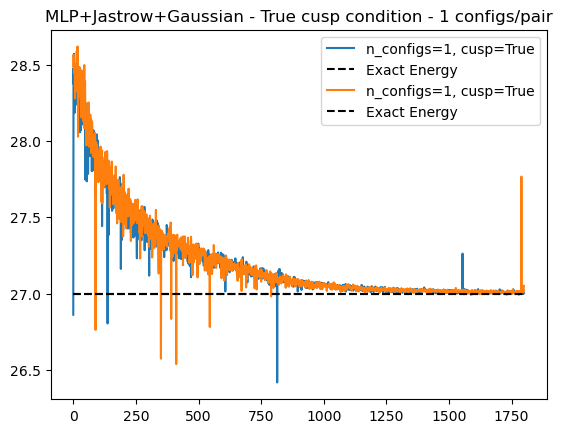

2 n_configs


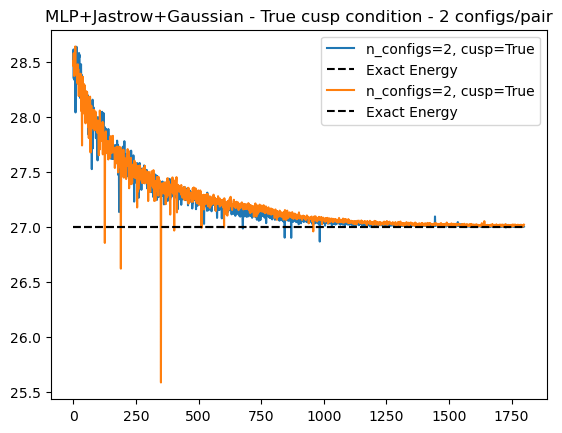

Model: Analytic
0 n_configs


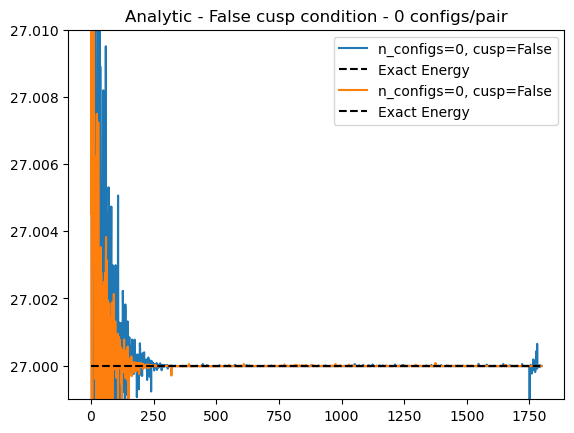

1 n_configs


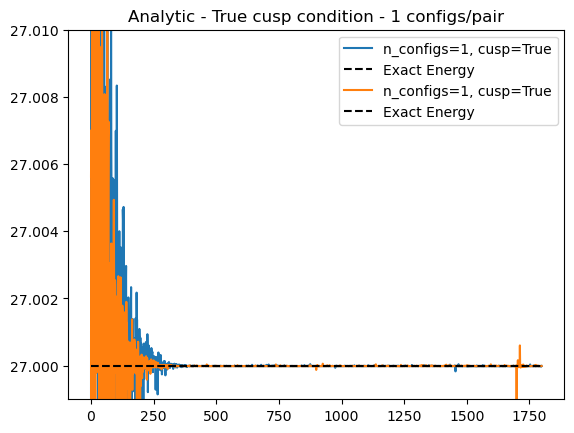

2 n_configs


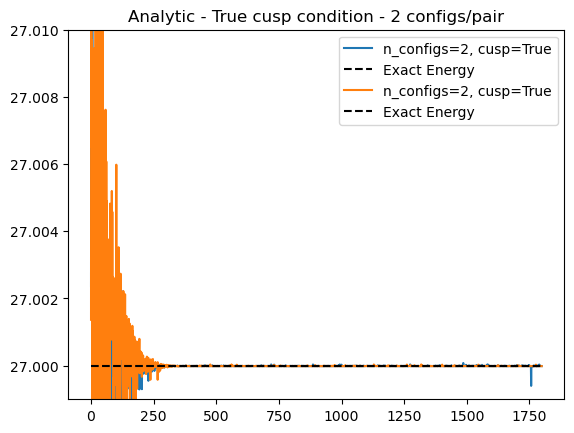

Model: MLP+Gaussian
0 n_configs


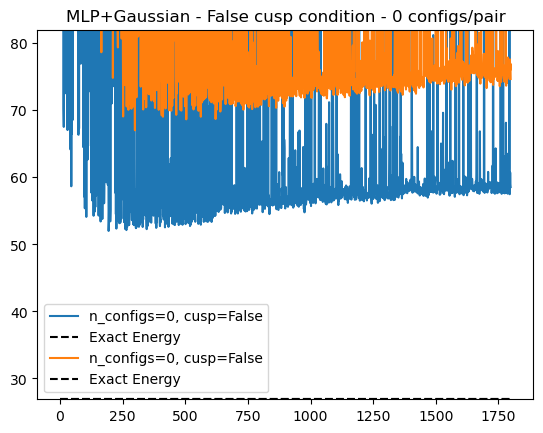

1 n_configs


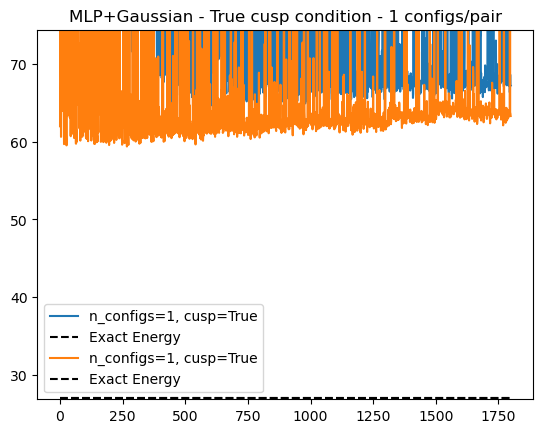

2 n_configs


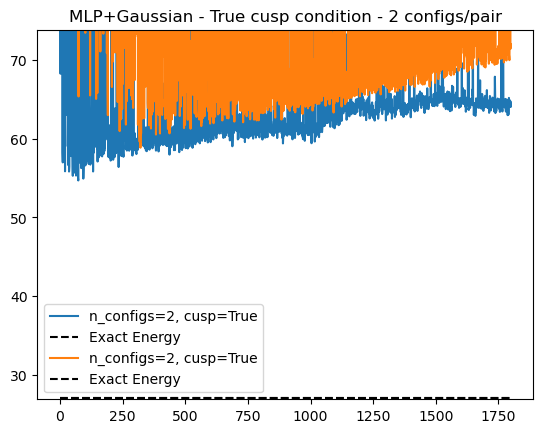

In [14]:
CUTOFF = 200  # skip the first 200 epochs for plotting, as they are usually very noisy and can have large energy values that mess up the scale of the plots

for model_name, model_results in collector.results.items():
    print(f"Model: {model_name}")
    # if model_name == "Analytic":
    for n_configs, results in model_results.items():
        print(n_configs, "n_configs")
        for result in results:
            plt.plot(result["energy"][CUTOFF:], label=f"n_configs={n_configs}, cusp={result['cusp']}")
            plt.hlines(E_EXACT_TOTAL, 0, len(result["energy"])-CUTOFF, colors='k', linestyles='dashed', label="Exact Energy")
            if model_name == "Analytic":
                plt.ylim(E_EXACT_TOTAL-0.001, E_EXACT_TOTAL+0.01)
            elif model_name == "MLP+Gaussian":
                plt.ylim(E_EXACT_TOTAL-0.1, min(result["energy"])+15)
        plt.title(f"{model_name} - {results[0]['cusp']} cusp condition - {n_configs} configs/pair")
        plt.legend()
        plt.show()